In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import os
import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None
from IPython.display import display

In [3]:
file_path = os.path.join("..", "data", "processed", "removed_high_corr.csv")

# Read CSV with index_col=0 to avoid unnamed column issues
data = pd.read_csv(file_path, index_col=0)
data

,Study_Prog_Exam_Completed,Study_Prog_Group_Size,Student_Enrollment_Gap,Exit_Status,Study_Prog_Name_Accountancy,Study_Prog_Name_Allied_Medical_Care,Study_Prog_Name_Arts_Therapies,Study_Prog_Name_Bachelor_of_Law,Study_Prog_Name_Biology_Medical_Laboratory_Research,Study_Prog_Name_Built_Environment,Study_Prog_Name_Business_Administration,Study_Prog_Name_Cesar_Kinetics_Therapy,Study_Prog_Name_Chemical_Engineering,Study_Prog_Name_Chemistry,Study_Prog_Name_Communication,Study_Prog_Name_Communication_and_Multimedia_Design,Study_Prog_Name_Creative_Business,Study_Prog_Name_Dental_Hygiene,Study_Prog_Name_Educational_Theory,Study_Prog_Name_Electrical_and_Electronic_Engineering,Study_Prog_Name_Entrepreneurship_Retail_Management,Study_Prog_Name_Facility_Management,Study_Prog_Name_Finance_Control,Study_Prog_Name_Finance_Tax_and_Advice,Study_Prog_Name_Health_Care_Management,Study_Prog_Name_Human_Resource_Management,Study_Prog_Name_Industrial_Engineering_Management,Study_Prog_Name_Information_Communication_Technology,Study_Prog_Name_International_Business_Utrecht,Study_Prog_Name_Interpreter,Study_Prog_Name_Journalism,Study_Prog_Name_Logistics_Management,Study_Prog_Name_Marketing_Management,Study_Prog_Name_Mechanical_Engineering,Study_Prog_Name_Nursing,Study_Prog_Name_Optometry,Study_Prog_Name_Orthoptics,Study_Prog_Name_Pharmaceutical_Business_Administration,Study_Prog_Name_Physiotherapy,Study_Prog_Name_Primary_Education,Study_Prog_Name_Safety_and_Security_Management,Study_Prog_Name_Skin_Therapy,Study_Prog_Name_Social_Legal_Services,Study_Prog_Name_Social_Work,Study_Prog_Name_Speech_and_Language_Therapy,Study_Prog_Name_Teacher_Education,Prior_Edu_Type_EDUCATIE,Prior_Edu_Type_HAVO,Prior_Edu_Type_HBO,Prior_Edu_Type_MBO,Prior_Edu_Type_OVERIG,Prior_Edu_Type_Others,Prior_Edu_Type_VWO,Prior_Edu_School_Location_'S-GRAVENHAGE,Prior_Edu_School_Location_'S-HERTOGENBOSCH,Prior_Edu_School_Location_0000_ABROAD,Prior_Edu_School_Location_ALKMAAR,Prior_Edu_School_Location_ALMELO,Prior_Edu_School_Location_ALMERE,Prior_Edu_School_Location_ALPHEN_AAN_DEN_RIJN,Prior_Edu_School_Location_AMERSFOORT,Prior_Edu_School_Location_AMSTELVEEN,Prior_Edu_School_Location_AMSTERDAM,Prior_Edu_School_Location_APELDOORN,Prior_Edu_School_Location_ARNHEM,Prior_Edu_School_Location_ASSEN,Prior_Edu_School_Location_BAARN,Prior_Edu_School_Location_BARNEVELD,Prior_Edu_School_Location_BERGEN_NH,Prior_Edu_School_Location_BILTHOVEN,Prior_Edu_School_Location_BREDA,Prior_Edu_School_Location_BREUKELEN,Prior_Edu_School_Location_BUSSUM,Prior_Edu_School_Location_CAPELLE_AAN_DEN_IJSSEL,Prior_Edu_School_Location_CASTRICUM,Prior_Edu_School_Location_CULEMBORG,Prior_Edu_School_Location_DELFT,Prior_Edu_School_Location_DEVENTER,Prior_Edu_School_Location_DOETINCHEM,Prior_Edu_School_Location_DOORN,Prior_Edu_School_Location_DOORWERTH,Prior_Edu_School_Location_DORDRECHT,Prior_Edu_School_Location_EDE,Prior_Edu_School_Location_EINDHOVEN,Prior_Edu_School_Location_ELBURG,Prior_Edu_School_Location_ENSCHEDE,Prior_Edu_School_Location_ERMELO,Prior_Edu_School_Location_ETTEN-LEUR,Prior_Edu_School_Location_GORINCHEM,Prior_Edu_School_Location_GOUDA,Prior_Edu_School_Location_GRONINGEN,Prior_Edu_School_Location_HAARLEM,Prior_Edu_School_Location_HARDERWIJK,Prior_Edu_School_Location_HELMOND,Prior_Edu_School_Location_HENGELO_OV,Prior_Edu_School_Location_HILVERSUM,Prior_Edu_School_Location_HOOFDDORP,Prior_Edu_School_Location_HOORN_NH,Prior_Edu_School_Location_HOUTEN,Prior_Edu_School_Location_HUIZEN,Prior_Edu_School_Location_IJSSELSTEIN,Prior_Edu_School_Location_LAREN_NH,Prior_Edu_School_Location_LEERDAM,Prior_Edu_School_Location_LEEUWARDEN,Prior_Edu_School_Location_LEIDEN,Prior_Edu_School_Location_LELYSTAD,Prior_Edu_School_Location_MAARSSEN,Prior_Edu_School_Location_MAASTRICHT,Prior_Edu_School_Location_MIJDRECHT,Prior_Edu_School_Location_NIEUWEGEIN,Prior_Edu_School_Location_NIJKERK,Prior_Edu_School_Location_NIJMEGEN,Prior_Edu_School_Location_ONBEKEND,Prior_Edu_School_Location_Others,Prior_Edu_School_Location_PAPENDRECHT,Prio

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Define features (X) and target (y)
X = data.drop(columns=['Exit_Status'])  # Drop target column
y = data['Exit_Status']  # Target variable

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Define RFE with Cross-Validation (10 folds)
rfecv = RFECV(
    estimator=rf_model, 
    step=1, 
    cv=StratifiedKFold(n_splits=10), 
    scoring='accuracy', 
    n_jobs=-1
)

# Fit the RFE model
rfecv.fit(X, y)

# Get selected features
selected_features = X.columns[rfecv.support_]

# Print results
print(f"Optimal number of features: {rfecv.n_features_}")
print("Selected Features:")
print(selected_features)


Optimal number of features: 57
Selected Features:
Index(['Study_Prog_Exam_Completed', 'Study_Prog_Group_Size',
       'Student_Enrollment_Gap', 'Study_Prog_Name_Bachelor_of_Law',
       'Study_Prog_Name_Biology_Medical_Laboratory_Research',
       'Study_Prog_Name_Built_Environment',
       'Study_Prog_Name_Business_Administration',
       'Study_Prog_Name_Communication',
       'Study_Prog_Name_Communication_and_Multimedia_Design',
       'Study_Prog_Name_Information_Communication_Technology',
       'Study_Prog_Name_International_Business_Utrecht',
       'Study_Prog_Name_Journalism', 'Study_Prog_Name_Marketing_Management',
       'Study_Prog_Name_Nursing',
       'Study_Prog_Name_Pharmaceutical_Business_Administration',
       'Study_Prog_Name_Primary_Education',
       'Study_Prog_Name_Safety_and_Security_Management',
       'Study_Prog_Name_Social_Legal_Services', 'Study_Prog_Name_Social_Work',
       'Study_Prog_Name_Teacher_Education', 'Prior_Edu_Type_HAVO',
       'Prior_Edu_Ty

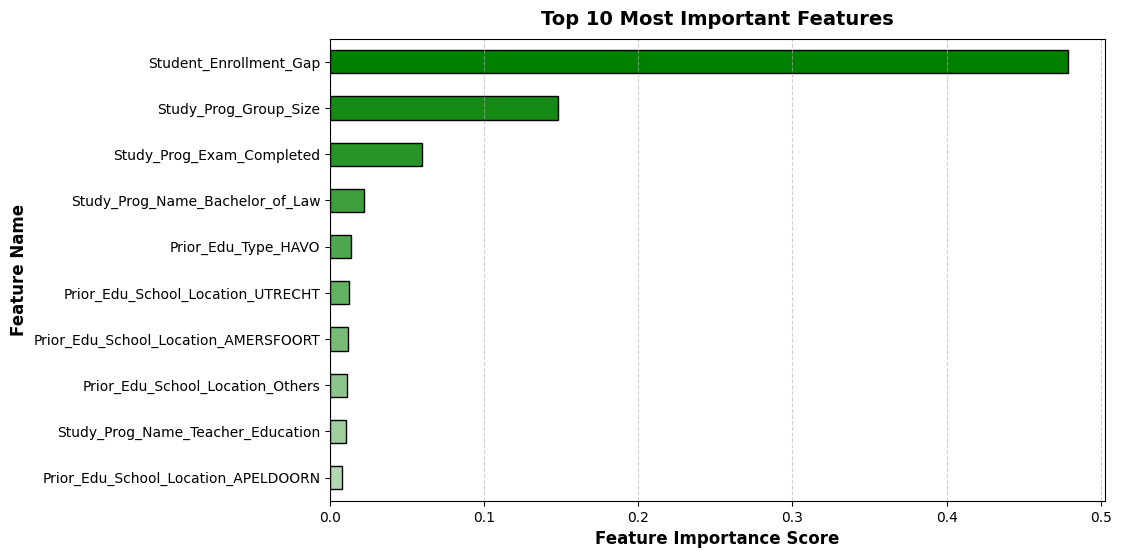

Subset Data Ready for Prediction:


,Study_Prog_Exam_Completed,Study_Prog_Group_Size,Student_Enrollment_Gap,Study_Prog_Name_Bachelor_of_Law,Study_Prog_Name_Biology_Medical_Laboratory_Research,Study_Prog_Name_Built_Environment,Study_Prog_Name_Business_Administration,Study_Prog_Name_Communication,Study_Prog_Name_Communication_and_Multimedia_Design,Study_Prog_Name_Information_Communication_Technology,Study_Prog_Name_International_Business_Utrecht,Study_Prog_Name_Journalism,Study_Prog_Name_Marketing_Management,Study_Prog_Name_Nursing,Study_Prog_Name_Pharmaceutical_Business_Administration,Study_Prog_Name_Primary_Education,Study_Prog_Name_Safety_and_Security_Management,Study_Prog_Name_Social_Legal_Services,Study_Prog_Name_Social_Work,Study_Prog_Name_Teacher_Education,Prior_Edu_Type_HAVO,Prior_Edu_Type_MBO,Prior_Edu_Type_OVERIG,Prior_Edu_School_Location_'S-GRAVENHAGE,Prior_Edu_School_Location_'S-HERTOGENBOSCH,Prior_Edu_School_Location_0000_ABROAD,Prior_Edu_School_Location_ALPHEN_AAN_DEN_RIJN,Prior_Edu_School_Location_AMERSFOORT,Prior_Edu_School_Location_AMSTERDAM,Prior_Edu_School_Location_APELDOORN,Prior_Edu_School_Location_ARNHEM,Prior_Edu_School_Location_BILTHOVEN,Prior_Edu_School_Location_BUSSUM,Prior_Edu_School_Location_CULEMBORG,Prior_Edu_School_Location_DOORN,Prior_Edu_School_Location_EDE,Prior_Edu_School_Location_GORINCHEM,Prior_Edu_School_Location_GOUDA,Prior_Edu_School_Location_HAARLEM,Prior_Edu_School_Location_HARDERWIJK,Prior_Edu_School_Location_HILVERSUM,Prior_Edu_School_Location_HOUTEN,Prior_Edu_School_Location_HUIZEN,Prior_Edu_School_Location_LEIDEN,Prior_Edu_School_Location_MAARSSEN,Prior_Edu_School_Location_NIEUWEGEIN,Prior_Edu_School_Location_NIJMEGEN,Prior_Edu_School_Location_Others,Prior_Edu_School_Location_ROTTERDAM,Prior_Edu_School_Location_SOEST,Prior_Edu_School_Location_TIEL,Prior_Edu_School_Location_UTRECHT,Prior_Edu_School_Location_VEENENDAAL,Prior_Edu_School_Location_VLEUTEN,Prior_Edu_School_Location_WOERDEN,Prior_Edu_School_Location_ZEIST,Prior_Edu_School_Location_ZWOLLE,Exit_Status
0,1,347,164.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,2
1,0,347,68.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
2,1,347,49.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,0,347,11.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
4,1,347,63.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48386,0,1663,51.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
48387,0,1663,51.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
48388,1,1663,-16.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
48389,0,1663,99.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2


In [10]:
# Get selected features based on RFE support mask
selected_features = X.columns[rfecv.support_]  # Only keep selected features

# Extract feature importances for the selected features
feature_importances = pd.Series(rfecv.estimator_.feature_importances_, index=selected_features)

# Get the top 10 most important features
top_features = feature_importances.nlargest(10)

# Reverse the gradient so the top bar is darkest
num_features = len(top_features)
colors = [(0, 0.5, 0, alpha) for alpha in np.linspace(0.3, 1, num_features)]  # Darker green at the top

# Plot feature importance with reversed green gradient
plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color=colors, edgecolor='black')

plt.xlabel("Feature Importance Score", fontsize=12, fontweight="bold")
plt.ylabel("Feature Name", fontsize=12, fontweight="bold")
plt.title("Top 10 Most Important Features", fontsize=14, fontweight="bold", pad=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Create a new DataFrame with the selected features + target variable
data_subset = data[selected_features.tolist() + ['Exit_Status']]

# Display first few rows of the subset data
print("Subset Data Ready for Prediction:")
data_subset
